In [1]:
import re
import json
import time
import numpy as np
import pandas as pd
from gensim.models import KeyedVectors
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI

/home/fabio.carrella/vllm_0.11.2/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [11]:
GLOVE_MODEL_PATH = "/home/fabio.carrella/teaching/MO850/session_12_agents/glove.kv.txt"

SBERT_MODEL_PATH    = "/home/fabio.carrella/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L12-v2/snapshots/c004d8e3e901237d8fa7e9fff12774962e391ce5"  # or local path

DATA_PATH           = "session_12_agents/DS_H2020JITSUVAX_WP2.1_TaxonomyFreeTextResponses_US_V8_FILTERED_WIDE.csv"
TEXT_COLUMN         = "text"                      # open-text column in df
OUTPUT_PATH         = "/path/to/output_scores.csv"

BACKEND = "vllm"   # "vllm" or "ollama"
 
if BACKEND == "vllm":
    BASE_URL   = "http://localhost:8000/v1"
    MODEL_NAME = "gpt"  # match what you launched vLLM with
elif BACKEND == "ollama":
    BASE_URL   = "http://localhost:11434/v1"
    MODEL_NAME = "mistral"                              # match what you pulled in ollama
 
TEMPERATURE = 0.0    
MAX_TOKENS  = 2048

client = OpenAI(base_url=BASE_URL, api_key="not-needed")

In [4]:
vax_items_antivax = {
    "consp": [
        "The authorities are lying and covering up important information about the vaccine.",
        "Big Pharma is colluding with the medical authorities to profit from people getting vaccinated.",
        "Some vaccines contain microchips that will be used to control us.",
        "To get us vaccinated, medical authorities are spreading fear about diseases that do not exist or are fabricated.",
        "Vaccination campaigns are targeted at weakening disadvantaged groups, minorities, and poor countries."
    ],

    "distr": [
        "When it comes to vaccines, doctors do not know what they are doing and do not care about patients.",
        "Research on vaccine safety is based on biased or incomplete data.",
        "The alleged scientific studies on vaccines are based on discredited theories and flawed methodologies.",
        "Medical authorities are overreacting, with vaccines being recommended for every minor illness now.",
        "Information from Big Pharma about vaccines is not to be trusted.",
        "Healthcare authorities, politicians, and governments are corrupt and profit from vaccinations.",
        "There is not enough safety testing, and no one is liable if someone is harmed by the vaccine.",
        "Powerful groups oppress disadvantaged groups and genders by imposing vaccination.",
        "People should do their own research and decide rather than following so-called experts."
    ],

    "unwar": [
        "Vaccines are not as good as traditional and natural remedies, such as homeopathy, which have a similar record of healing and no side effects.",
        "Vaccines interfere with the body's natural immunity, which provides a better defense against the disease.",
        "People are being offered too many vaccines nowadays, and this will overload their immune systems.",
        "Instead of vaccines, people should improve environmental factors like good hygiene, healthy lifestyles, and protective measures against the disease.",
        "Scientists are still debating the benefits of vaccination, and the science is not settled.",
        "Vaccines contain viruses and can cause the disease they are supposed to prevent.",
        "Vaccinated people spread the disease they got vaccinated against, making the healthy and unvaccinated sick.",
        "It cannot be a coincidence that when vaccination rates increased, so did case rates and death rates.",
        "The disease will disappear on its own, following a natural cycle."
    ],

    "world": [
        "Vaccines are just another way that the scientific elite are widening inequalities and subjugating ordinary people.",
        "Vaccinations are an expression of the inappropriate interference of the state in the freedoms of individual citizens.",
        "Politicians use vaccinations as strategies to boost their own political agendas at the expense of the common good.",
        "Adhering to one's own traditional, cultural rules is more important than following vaccination guidelines.",
        "Vaccines are a modern invention and I try to avoid modern technology as much as possible."
    ],

    "relig": [
        "Vaccines contain products that are forbidden by my religion.",
        "Vaccines interfere with God's will: He will decide if people get the disease or not.",
        "People should abide by what religious leaders say against vaccines.",
        "The human body was created in God's image, so it is a sin to defile it with unnatural injections.",
        "Not allowing religious exemptions to vaccines is discriminatory."
    ],

    "moral": [
        "Vaccines were developed through unethical experimentation.",
        "People should not accept vaccines that are produced using tissues from aborted fetuses.",
        "Sexual abstention is preferable to taking the human papillomavirus (HPV) vaccine, which would only promote promiscuity.",
        "Profit-driven vaccination campaigns are immoral.",
        "It's our moral duty not to rely on vaccines.",
        "Parents who rely on vaccination for their child's health demonstrate poor values."
    ],

    "fears": [
        "I worry about experiencing side effects from the vaccine.",
        "Vaccines are not safe.",
        "Vaccines cause severe injuries and people never recover from them.",
        "Vaccines contaminate the human body with toxins, heavy metals or viruses that could alter DNA.",
        "Vaccines should not be administered to vulnerable people, such as pregnant women, young children or patients with allergies.",
        "Vaccines overwhelm the immune system, especially when taken in many doses.",
        "I'm afraid of needles and fear the vaccination will hurt."
    ],

    "disto": [
        "Vaccines are unnecessary and not a medical priority.",
        "Vaccine-preventable diseases are mild and can be easily treated.",
        "Vaccinations are not needed if you live in a developed and safe country.",
        "Vaccines are riskier than the diseases themselves.",
        "Vaccinations are unnecessary if you have a strong immune system that protects you from vaccine-preventable diseases."
    ],

    "selfi": [
        "People do not need to be vaccinated as long as herd immunity exists.",
        "We should not take vaccines because other people do not take protective measures to stop spreading the disease.",
        "People should look after their own health rather than put themselves or their child at risk to protect others.",
        "Instead of vaccinations, people should just self-isolate to stop the spread of disease.",
        "People whose jobs allow them to adopt strong preventive measures against diseases should not need to get vaccinated."
    ],

    "epist": [
        "The theories on which vaccines are based are not objective or true but are a social construction by scientists that is being imposed on other equally valid perspectives.",
        "Negative experiences and testimonies of injuries by patients should be prioritized when deciding whether or not to accept vaccination.",
        "The vaccination movement does not respect alternative perspectives on health that are more comprehensive and holistic.",
        "People are experts on their own bodies so they may legitimately conclude based on their own reading that vaccination is not for them.",
        "The vaccine does not work for everyone, and we should not take risks with anything that is less than 100% effective."
    ],

    "react": [
        "Vaccination campaigns bully and harass people into getting a vaccine.",
        "People should be able to decide what goes into their bodies, so it should be a matter of free personal choice whether someone gets a vaccine.",
        "We need to resist an authoritarian state that is abusing its power and violating individual rights by telling us to get vaccinated.",
        "People are getting vaccinated out of ignorance and fear, according to what the nanny state expects of them.",
        "Everyone has the right to contract a disease if they want to."
    ]
}

vax_keywords_ddr = {
    "consp": [
        "conspiracy", "coverup", "microchip", "lies", "fabricated",
        "colluding", "hidden", "agenda", "surveillance", "manipulation"
    ],
    "distr": [
        "distrust", "corrupt", "biased", "profit", "untrustworthy",
        "flawed", "overreacting", "liability", "oppression", "research"
    ],
    "unwar": [
        "natural", "homeopathy", "immunity", "overload", "unnecessary",
        "hygiene", "debate", "spread", "cycle", "remedies"
    ],
    "world": [
        "freedom", "inequality", "elite", "tradition", "authoritarian",
        "political", "agenda", "culture", "technology", "subjugation"
    ],
    "relig": [
        "religion", "God", "faith", "sin", "forbidden",
        "prayer", "divine", "sacred", "scripture", "exemption"
    ],
    "moral": [
        "unethical", "immoral", "fetus", "exploitation", "promiscuity",
        "duty", "values", "experimentation", "profit", "aborted"
    ],
    "fears": [
        "side effects", "dangerous", "injury", "toxins", "needle",
        "unsafe", "DNA", "allergy", "dose", "contamination"
    ],
    "disto": [
        "unnecessary", "mild", "overblown", "risk", "priority",
        "developed", "immune", "treatable", "exaggerated", "manageable"
    ],
    "selfi": [
        "herd immunity", "individual", "isolate", "personal", "self-protect",
        "preventive", "others", "risk", "choice", "measures"
    ],
    "epist": [
        "subjective", "testimony", "holistic", "alternative", "social construction",
        "anecdote", "perspective", "personal", "reading", "effectiveness"
    ],
    "react": [
        "freedom", "autonomy", "rights", "bullying", "authoritarian",
        "coercion", "nanny", "resist", "liberty", "mandate"
    ]
}
 
FACETS = list(vax_items_antivax.keys())

FACET_TO_SURVEY = {
    "consp": "consp01",
    "distr": "distr04",
    "unwar": "unwar03",
    "world": "world02",
    "relig": "relig04",
    "moral": "moral01",
    "fears": "fears06",
    "disto": "disto04",
    "selfi": "selfi05",
    "epist": "epist01",
    "react": "react04",
}

ITEMS = {
    "consp01": "The authorities are lying and covering up important information about the vaccine.",
    "distr04": "Medical authorities are overreacting, with vaccines being recommended for every minor illness now.",
    "unwar03": "Vaccines interfere with the body's natural immunity, which is a better defense against the disease.",
    "world02": "Vaccinations are an expression of the inappropriate interference of the state in the freedoms of individual citizens.",
    "relig04": "The human body was created in God's image, so it is a sin to defile it with unnatural injections.",
    "moral01": "It's our moral duty not to rely on vaccines.",
    "fears06": "Vaccines are not safe.",
    "disto04": "Vaccines are riskier than the diseases themselves.",
    "selfi05": "People whose jobs allow them to adopt strong preventive measures against diseases should not need to get vaccinated.",
    "epist01": 'The "theories" on which vaccines are based are not "objective" or "true" but are a social construction by scientists that is being imposed on other equally valid perspectives.',
    "react04": "We need to resist an authoritarian state that is abusing its power and violating individual rights by telling us to get vaccinated.",
}

ITEMS_BLOCK = "\n".join(
    f'{col}: "{text}"' for col, text in ITEMS.items()
)
 
SYSTEM_PROMPT = """\
You are simulating a survey participant. You will be given a text written by a person \
explaining why they have a negative opinion towards vaccines. Your task is to answer \
a set of survey items AS IF YOU WERE THAT PERSON, based strictly on what they expressed \
in their text.
 
Each item is rated on a Likert scale where:
1 = strongly disagree
2 = disagree
3 = neither agree nor disagree
4 = agree
5 = strongly agree
 
Reply ONLY with a valid JSON object mapping each item code to an integer (1–5). \
No explanation, no markdown, no extra text. Example format:
{"consp01": 3, "distr04": 4, "unwar03": 2, "world02": 5, "relig04": 1, \
"moral01": 2, "fears06": 4, "disto04": 3, "selfi05": 2, "epist01": 3, "react04": 4}
"""

In [19]:
def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""
 
def mean_word_vector(words):
    tokens = []
    for w in words:
        tokens.extend(w.lower().split())
    vecs = [wv[t] for t in tokens if t in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(VECTOR_DIM)
 
def document_vector(text):
    tokens = text.lower().split()
    vecs = [wv[t] for t in tokens if t in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(VECTOR_DIM)
 
def build_user_prompt(text):
    return (
        f'The participant wrote the following in response to the question '
        f'"Why do you have a negative opinion towards vaccines?":\n\n'
        f'"""{text}"""\n\n'
        f'Now answer these survey items as that participant '
        f'(1 = strongly disagree, 5 = strongly agree):\n\n'
        f'{ITEMS_BLOCK}\n\nReply ONLY with a JSON object.'
    )
 
def parse_response(raw):
    try:
        return json.loads(raw.strip())
    except json.JSONDecodeError:
        pass
    match = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass
    return None
 
def clamp(val, lo=1, hi=5):
    try:
        return max(lo, min(hi, int(round(float(val)))))
    except (TypeError, ValueError):
        return None
 
def correlate(df, score_col, survey_col, method=stats.pearsonr):
    subset = (
        df[[score_col, survey_col]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
    )

    if len(subset) < 10:
        return len(subset), np.nan, np.nan

    r, p = method(subset[score_col], subset[survey_col])

    return len(subset), round(r, 4), round(p, 4)

In [6]:
print("Loading GloVe/Word2Vec model...")
wv = KeyedVectors.load_word2vec_format(GLOVE_MODEL_PATH, binary=False)
VECTOR_DIM = wv.vector_size
 
print("Loading SBERT model...")
sbert = SentenceTransformer(SBERT_MODEL_PATH)
 
print("Loading data...")
df = pd.read_csv(DATA_PATH)
texts = df[TEXT_COLUMN].fillna("").tolist()
print(f"  {len(texts)} rows loaded")

Loading GloVe/Word2Vec model...
Loading SBERT model...
Loading data...
  556 rows loaded


In [7]:
print("Building DDR reference vectors (GloVe + keywords)...")
ddr_ref_matrix = normalize(
    np.vstack([mean_word_vector(vax_keywords_ddr[f]) for f in FACETS])
)
 
print("Extracting GloVe document vectors...")
ddr_doc_matrix = normalize(np.vstack([document_vector(t) for t in texts]))
 
ddr_sims = cosine_similarity(ddr_doc_matrix, ddr_ref_matrix)  # (N, 11)
for i, facet in enumerate(FACETS):
    df[f"ddr_{facet}"] = ddr_sims[:, i]

Building DDR reference vectors (GloVe + keywords)...
Extracting GloVe document vectors...


In [8]:
print("Building CCR reference vectors (SBERT + items)...")
ccr_ref_matrix = normalize(
    np.vstack([
        sbert.encode(vax_items_antivax[f], batch_size=64, convert_to_numpy=True).mean(axis=0)
        for f in FACETS
    ])
)
 
print("Extracting SBERT document embeddings...")
ccr_doc_matrix = normalize(
    sbert.encode(texts, batch_size=64, convert_to_numpy=True, show_progress_bar=True)
)
 
ccr_sims = cosine_similarity(ccr_doc_matrix, ccr_ref_matrix)  # (N, 11)
for i, facet in enumerate(FACETS):
    df[f"ccr_{facet}"] = ccr_sims[:, i]

Building CCR reference vectors (SBERT + items)...
Extracting SBERT document embeddings...


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

In [15]:
print("Running LLM scoring...")
for col in ITEMS:
    df[f"llm_{col}"] = np.nan
 
failed = []
for i, text in enumerate(texts):
    if i % 50 == 0:
        print(f"  {i}/{len(texts)}")
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": build_user_prompt(text)},
            ],
            temperature=TEMPERATURE,
            max_tokens=MAX_TOKENS,
        )
        parsed = parse_response(response.choices[0].message.content)
        if parsed is None:
            failed.append((i, "parse_error", response.choices[0].message.content[:120]))
            continue
        for col in ITEMS:
            val = clamp(parsed.get(col))
            if val is not None:
                df.at[i, f"llm_{col}"] = val
            else:
                failed.append((i, f"missing_{col}", str(parsed)[:120]))
    except Exception as e:
        failed.append((i, "api_error", str(e)))
    #time.sleep(SLEEP_SEC)
 
print(f"LLM done. Failed: {len(failed)}")
if failed:
    for row in failed[:5]:
        print(row)

Running LLM scoring...
  0/556
  50/556
  100/556
  150/556
  200/556
  250/556
  300/556
  350/556
  400/556
  450/556
  500/556
  550/556
LLM done. Failed: 3
(71, 'api_error', "'NoneType' object has no attribute 'strip'")
(231, 'api_error', "'NoneType' object has no attribute 'strip'")
(528, 'api_error', "'NoneType' object has no attribute 'strip'")


In [ ]:
spearmanr()

In [20]:
ddr_records, ccr_records, llm_records = [], [], []
 
for facet, survey_col in FACET_TO_SURVEY.items():
    n, r_ddr, p_ddr = correlate(df, f"ddr_{facet}", survey_col, method=stats.spearmanr)
    n, r_ccr, p_ccr = correlate(df, f"ccr_{facet}", survey_col, method=stats.spearmanr)
    n, r_llm, p_llm = correlate(df, f"llm_{survey_col}", survey_col, method=stats.spearmanr)
 
    base = {"facet": facet, "survey_item": survey_col, "n": n}
    ddr_records.append({**base, "r_ddr": r_ddr, "p_ddr": p_ddr, "sig_ddr": stars(p_ddr) if not np.isnan(p_ddr) else ""})
    ccr_records.append({**base, "r_ccr": r_ccr, "p_ccr": p_ccr, "sig_ccr": stars(p_ccr) if not np.isnan(p_ccr) else ""})
    llm_records.append({**base, "r_llm": r_llm, "p_llm": p_llm, "sig_llm": stars(p_llm) if not np.isnan(p_llm) else ""})
 
ddr_results = pd.DataFrame(ddr_records)
ccr_results = pd.DataFrame(ccr_records)
llm_results = pd.DataFrame(llm_records)
 
# Merge into one summary table
results = (
    ddr_results
    .merge(ccr_results.drop(columns=["survey_item", "n"]), on="facet")
    .merge(llm_results.drop(columns=["survey_item", "n"]), on="facet")
)
 
print("\n── Correlation summary ──")
print(results[["facet", "n", "r_ddr", "sig_ddr", "r_ccr", "sig_ccr", "r_llm", "sig_llm"]].to_string(index=False))


── Correlation summary ──
facet   n   r_ddr sig_ddr   r_ccr sig_ccr  r_llm sig_llm
consp 553  0.1715     ***  0.1620     *** 0.2801     ***
distr 553  0.0255          0.1249      ** 0.3711     ***
unwar 553  0.0097         -0.0172         0.4089     ***
world 553  0.1253      **  0.0875       * 0.3071     ***
relig 553  0.0295          0.1595     *** 0.1625     ***
moral 553  0.0697          0.1256      ** 0.3151     ***
fears 553  0.0044          0.1807     *** 0.4618     ***
disto 553 -0.0718          0.0017         0.4011     ***
selfi 553  0.1796     ***  0.1598     *** 0.2063     ***
epist 553 -0.1001       *  0.0210         0.2266     ***
react 553  0.1079       *  0.1618     *** 0.2660     ***


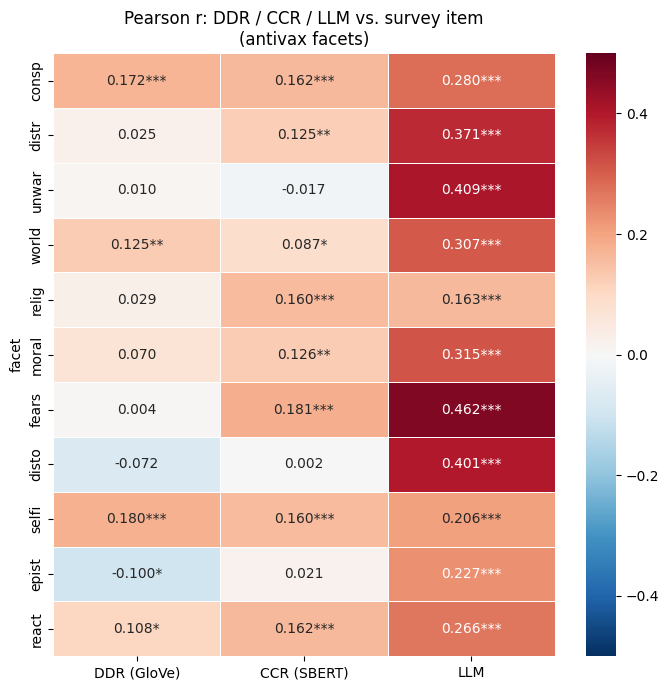

In [21]:
heat_data = results.set_index("facet")[["r_ddr", "r_ccr", "r_llm"]].rename(
    columns={"r_ddr": "DDR (GloVe)", "r_ccr": "CCR (SBERT)", "r_llm": "LLM"}
)
 
annot_matrix = pd.DataFrame(
    {
        "DDR (GloVe)": [f"{r:.3f}{s}" if not pd.isna(r) else "—"
                        for r, s in zip(results["r_ddr"], results["sig_ddr"])],
        "CCR (SBERT)": [f"{r:.3f}{s}" if not pd.isna(r) else "—"
                        for r, s in zip(results["r_ccr"], results["sig_ccr"])],
        "LLM":         [f"{r:.3f}{s}" if not pd.isna(r) else "—"
                        for r, s in zip(results["r_llm"], results["sig_llm"])],
    },
    index=results["facet"],
)
 
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(
    heat_data,
    annot=annot_matrix,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-0.5,
    vmax=0.5,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Pearson r: DDR / CCR / LLM vs. survey item\n(antivax facets)", fontsize=12)
plt.tight_layout()
plt.savefig("facet_correlation_heatmap_all.png", dpi=150)
plt.show()